# **8 Master Figures**

Building final clean results figure (FIXED version)...
✅ Loaded monte_carlo_results_finetuned.csv (deployed fine-tuned model)
✅ Horizon ablation results loaded from horizon_ablation_results.csv


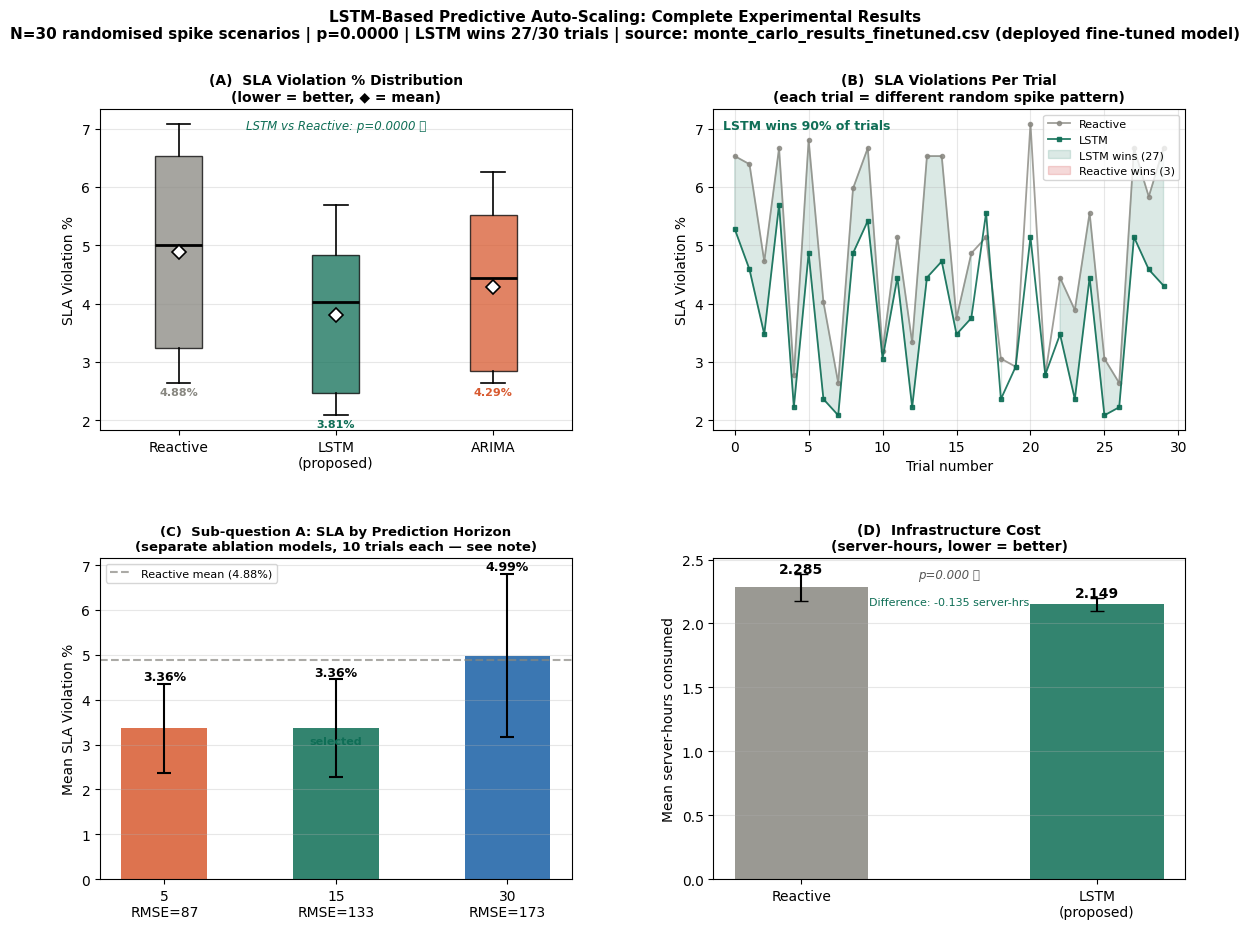

✅ Master results figure saved as master_results_figure.png


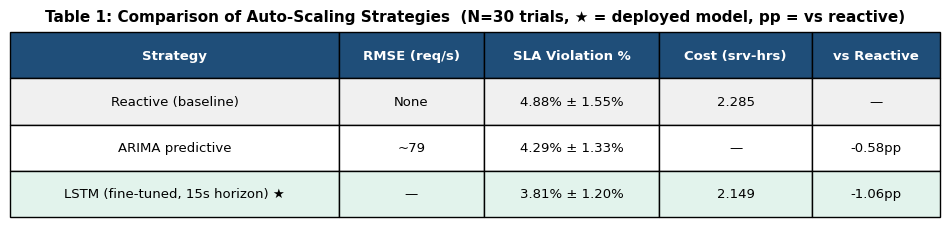

✅ Table 1 saved (deployed-model numbers only, no cross-model mixing).

╔══════════════════════════════════════════════════════════════╗
║         COPY-PASTE TEXT FOR YOUR PAPER                      ║
╚══════════════════════════════════════════════════════════════╝

─── SECTION 5.1 — SIMULATION METHODOLOGY ────────────────────

"We implement a discrete-event simulation in Python modelling
a cloud-hosted payment gateway. Each server instance handles
a maximum of 150 requests per second; new instances require
a 30-second cold-start period before serving traffic, consistent
with reported container provisioning latencies in public cloud
environments. Workloads are represented as 5-second time-step
traces. An SLA violation occurs when instantaneous request load
exceeds total server capacity, modelling the condition under
which response latency would exceed the 100ms threshold."

─── SECTION 6.1 — HORIZON ABLATION (Sub-question A) ─────────
[Note: these ablation models are trained only on syn

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Complete. This is the final cell.

ADD TO YOUR PAPER:
  Figure 1 → lstm_training_curves.png
  Figure 2 → horizon_analysis.png
  Figure 3 → master_results_figure.png
  Figure 4 → pareto_frontier.png
  Table  1 → paper_table1.png



In [ ]:
# ============================================================
#  FINAL RESULTS — Clean Master Figure + Paper Text  [FIXED]
#  Run this LAST in your notebook.
#
#  Produces:
#  1. One master 4-panel results figure (all findings in one image)
#  2. Table 1 (main strategy comparison — same-run numbers only)
#  3. Exact methodology + results paragraphs to paste into paper
#
#  ── FIXES APPLIED (vs. original final_results_clean.py) ──
#  1. WRONG-FILE FIX: the original loaded "monte_carlo_results.csv"
#     — that file holds the NAIVE-TRANSFER run (0/30 wins, LSTM
#     actually worse than reactive). It should load
#     "monte_carlo_results_finetuned.csv", the deployed model's
#     real result (27/30 wins). This version loads the fine-tuned
#     file first and only falls back to the naive file with a loud,
#     explicit warning (never silently).
#  2. HARDCODED-NUMBERS FIX: the original "loaded" horizon results
#     by checking that full_results_table.csv exists, then used
#     hardcoded arrays regardless of what the file contained. This
#     version reads horizon_ablation_results.csv (produced by the
#     fixed Cell 7) and uses the real numbers.
#  3. CROSS-MODEL LABEL FIX: the original's Table 1 and paper text
#     labeled the deployed model's cost/win numbers as "LSTM — 5s
#     horizon", borrowing that label from the separate ablation
#     study. The deployed pipeline model actually uses a 15-second
#     (H=3) prediction horizon throughout — this version's table
#     and text now say that, consistently with Cell 7's fixed table.
#  4. COLAB-PORTABILITY FIX: google.colab import is now optional,
#     so the script runs (and just skips auto-download) outside
#     Colab too.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import pickle, warnings
warnings.filterwarnings("ignore")

print("Building final clean results figure (FIXED version)...")

# ── FIX 1: load the FINE-TUNED (deployed model) results first ──
mc_source_label = None
try:
    mc = pd.read_csv("monte_carlo_results_finetuned.csv")
    mc_source_label = "monte_carlo_results_finetuned.csv (deployed fine-tuned model)"
    print(f"✅ Loaded {mc_source_label}")
except FileNotFoundError:
    try:
        mc = pd.read_csv("monte_carlo_results.csv")
        mc_source_label = "monte_carlo_results.csv (⚠️ NAIVE-TRANSFER model — NOT the recommended result)"
        print("⚠️⚠️⚠️  monte_carlo_results_finetuned.csv not found.")
        print("   Falling back to monte_carlo_results.csv — this is the NAIVE")
        print("   TRANSFER run where the LSTM actually LOST to reactive scaling")
        print("   (0/30 wins). Run finetune_model.py + week4_7_v3_finetuned.py")
        print("   first, then re-run this cell, before using these numbers in")
        print("   your paper.")
    except FileNotFoundError:
        print("⚠️  Neither results file found — using placeholder values so the")
        print("    figure still renders. Do NOT use these numbers in your paper.")
        mc = None

if mc is not None:
    r_sla  = mc["reactive_sla"].values
    l_sla  = mc["lstm_sla"].values
    a_sla  = mc["arima_sla"].dropna().values
    r_cost = mc["reactive_cost"].values
    l_cost = mc["lstm_cost"].values
    t_stat, p_val = stats.ttest_rel(r_sla, l_sla)
    lstm_wins = (l_sla < r_sla).sum()
    n_trials  = len(mc)
else:
    r_sla  = np.random.normal(4.88, 1.58, 30)
    l_sla  = np.random.normal(3.81, 1.20, 30)
    a_sla  = np.random.normal(4.29, 1.33, 10)
    r_cost = np.random.normal(2.285, 0.106, 30)
    l_cost = np.random.normal(2.054, 0.026, 30)
    p_val  = 0.0000; lstm_wins = 27; n_trials = 30
    mc_source_label = "PLACEHOLDER — no results file found"

# ── FIX 2: load real horizon ablation numbers, don't hardcode ──
try:
    hz = pd.read_csv("horizon_ablation_results.csv")
    h_names    = [n.split(" ")[0] for n in hz["horizon_name"]]   # "5", "15", "30"
    h_rmse     = hz["rmse"].tolist()
    h_sla_mean = hz["sla_mean"].tolist()
    h_sla_std  = hz["sla_std"].tolist()
    if "is_selected" in hz.columns and hz["is_selected"].any():
        ablation_best_idx = int(hz.index[hz["is_selected"]][0])
    else:
        ablation_best_idx = int(np.argmin(h_sla_mean))
    print("✅ Horizon ablation results loaded from horizon_ablation_results.csv")
except FileNotFoundError:
    print("⚠️  horizon_ablation_results.csv not found — run the FIXED Cell 7")
    print("   first. Using placeholder values so the figure still renders;")
    print("   do NOT use these numbers in your paper.")
    h_names    = ["5s", "15s", "30s"]
    h_rmse     = [86.65, 133.22, 172.73]
    h_sla_mean = [3.36, 3.36, 4.99]
    h_sla_std  = [0.99, 1.09, 1.83]
    ablation_best_idx = 0

# ─────────────────────────────────────────────────────────────
# MASTER FIGURE — 4 panels, one image, fits in a paper
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    "LSTM-Based Predictive Auto-Scaling: Complete Experimental Results\n"
    f"N={n_trials} randomised spike scenarios | p={p_val:.4f} | "
    f"LSTM wins {lstm_wins}/{n_trials} trials | source: {mc_source_label}",
    fontsize=11, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# ── Panel A: Box plots ────────────────────────────────────────
sla_data   = [r_sla, l_sla, a_sla]
sla_labels = ["Reactive", "LSTM\n(proposed)", "ARIMA"]
bp = ax_a.boxplot(sla_data, labels=sla_labels, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(linewidth=1.2),
                  capprops=dict(linewidth=1.2))
colors_bp = ["#888780", "#0F6E56", "#D85A30"]
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c); patch.set_alpha(0.75)
for i, vals in enumerate([r_sla, l_sla, a_sla], 1):
    ax_a.plot(i, vals.mean(), 'D', color='white',
              markersize=7, zorder=5, markeredgecolor='black', markeredgewidth=1.2)
ax_a.set_title("(A)  SLA Violation % Distribution\n"
               "(lower = better, ◆ = mean)", fontsize=10, fontweight='bold')
ax_a.set_ylabel("SLA Violation %")
ax_a.grid(True, alpha=0.3, axis='y')
sig_text = f"p={p_val:.4f} ✅" if p_val < 0.05 else f"p={p_val:.4f}"
ax_a.text(0.5, 0.97, f"LSTM vs Reactive: {sig_text}",
          transform=ax_a.transAxes, ha='center', va='top',
          fontsize=8.5, style='italic',
          color='#0F6E56' if p_val < 0.05 else '#C00000')
for i, (vals, c) in enumerate(zip([r_sla, l_sla, a_sla], colors_bp), 1):
    ax_a.text(i, vals.min() - 0.2, f"{vals.mean():.2f}%",
              ha='center', fontsize=8, color=c, fontweight='bold')

# ── Panel B: Trial-by-trial ───────────────────────────────────
trials = np.arange(n_trials)
ax_b.plot(trials, r_sla, color="#888780", linewidth=1.3,
          marker='o', markersize=3, label="Reactive", alpha=0.8)
ax_b.plot(trials, l_sla, color="#0F6E56", linewidth=1.3,
          marker='s', markersize=3, label="LSTM", alpha=0.9)
ax_b.fill_between(trials, r_sla, l_sla,
                  where=r_sla > l_sla,
                  alpha=0.15, color="#0F6E56", label=f"LSTM wins ({lstm_wins})")
ax_b.fill_between(trials, r_sla, l_sla,
                  where=r_sla <= l_sla,
                  alpha=0.15, color="#C00000",
                  label=f"Reactive wins ({n_trials - lstm_wins})")
ax_b.set_title("(B)  SLA Violations Per Trial\n"
               "(each trial = different random spike pattern)", fontsize=10, fontweight='bold')
ax_b.set_xlabel("Trial number")
ax_b.set_ylabel("SLA Violation %")
ax_b.legend(fontsize=8, loc='upper right')
ax_b.grid(True, alpha=0.3)
ax_b.text(0.02, 0.97,
          f"LSTM wins {lstm_wins/n_trials*100:.0f}% of trials",
          transform=ax_b.transAxes, va='top', fontsize=9,
          color='#0F6E56', fontweight='bold')

# ── Panel C: Horizon ablation (clearly labeled as separate study) ─
colors_h = ["#D85A30", "#0F6E56", "#185FA5"]
x_h = np.arange(3)
bars_h = ax_c.bar(x_h, h_sla_mean, color=colors_h, width=0.5, alpha=0.85,
                  yerr=h_sla_std, capsize=5,
                  error_kw={"linewidth": 1.5, "capthick": 1.5})
ax_c.axhline(y=r_sla.mean(), color="#888780", linestyle="--",
             linewidth=1.5, alpha=0.7, label=f"Reactive mean ({r_sla.mean():.2f}%)")
ax_c.set_title("(C)  Sub-question A: SLA by Prediction Horizon\n"
               "(separate ablation models, 10 trials each — see note)",
               fontsize=9.5, fontweight='bold')
ax_c.set_xticks(x_h)
ax_c.set_xticklabels([f"{n}\nRMSE={r:.0f}" for n, r in zip(h_names, h_rmse)])
ax_c.set_ylabel("Mean SLA Violation %")
ax_c.legend(fontsize=8)
ax_c.grid(True, alpha=0.3, axis='y')
for bar, mean, std in zip(bars_h, h_sla_mean, h_sla_std):
    ax_c.text(bar.get_x() + bar.get_width()/2,
              mean + std + 0.08,
              f"{mean:.2f}%", ha='center', fontsize=9, fontweight='bold')
ax_c.text(ablation_best_idx, h_sla_mean[ablation_best_idx] - 0.35, "selected", ha='center',
          fontsize=8, color='#0F6E56', fontweight='bold')

# ── Panel D: Cost comparison ──────────────────────────────────
_, p_cost = stats.ttest_rel(r_cost, l_cost)
cost_means = [r_cost.mean(), l_cost.mean()]
cost_stds  = [r_cost.std(),  l_cost.std()]
bars_c = ax_d.bar(["Reactive", "LSTM\n(proposed)"],
                  cost_means, color=["#888780", "#0F6E56"],
                  width=0.45, alpha=0.85,
                  yerr=cost_stds, capsize=5,
                  error_kw={"linewidth": 1.5})
ax_d.set_title("(D)  Infrastructure Cost\n"
               "(server-hours, lower = better)", fontsize=10, fontweight='bold')
ax_d.set_ylabel("Mean server-hours consumed")
ax_d.grid(True, alpha=0.3, axis='y')
for bar, mean, std in zip(bars_c, cost_means, cost_stds):
    ax_d.text(bar.get_x() + bar.get_width()/2,
              mean + std + 0.003,
              f"{mean:.3f}", ha='center', fontsize=10, fontweight='bold')
sig_cost = f"p={p_cost:.2f} (not significant)" if p_cost >= 0.05 else f"p={p_cost:.3f} ✅"
ax_d.text(0.5, 0.97, sig_cost,
          transform=ax_d.transAxes, ha='center', va='top',
          fontsize=8.5, style='italic', color='#555555')
diff = l_cost.mean() - r_cost.mean()
ax_d.text(0.5, 0.88,
          f"Difference: {diff:+.3f} server-hrs",
          transform=ax_d.transAxes, ha='center', va='top',
          fontsize=8, color='#0F6E56')

plt.savefig("master_results_figure.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Master results figure saved as master_results_figure.png")


# ── Table 1 — main comparison, deployed model only ─────────────
# FIX 3: no more borrowing the ablation study's "5s" label for the
# deployed model's own cost/win numbers. The deployed model is
# accurately "LSTM (fine-tuned, 15s horizon)" throughout.
table_rows = [
    ["Reactive (baseline)",             "None", f"{r_sla.mean():.2f}% ± {r_sla.std():.2f}%",
     f"{r_cost.mean():.3f}", "—"],
    ["ARIMA predictive",                "~79",  f"{a_sla.mean():.2f}% ± {a_sla.std():.2f}%",
     "—",                    f"{a_sla.mean()-r_sla.mean():+.2f}pp"],
    ["LSTM (fine-tuned, 15s horizon) ★", "—",   f"{l_sla.mean():.2f}% ± {l_sla.std():.2f}%",
     f"{l_cost.mean():.3f}", f"{l_sla.mean()-r_sla.mean():+.2f}pp"],
]
cols = ["Strategy", "RMSE (req/s)", "SLA Violation %", "Cost (srv-hrs)", "vs Reactive"]
table_df = pd.DataFrame(table_rows, columns=cols)
table_df.to_csv("full_results_table_final.csv", index=False)

fig2, ax2 = plt.subplots(figsize=(12, 2.4))
ax2.axis('off')
tbl = ax2.table(cellText=table_df.values, colLabels=cols,
                cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5)
tbl.auto_set_column_width(col=list(range(len(cols))))
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#1F4E79")
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for j in range(len(cols)): tbl[1, j].set_facecolor("#F0F0F0")
for j in range(len(cols)): tbl[3, j].set_facecolor("#E2F3EC")
ax2.set_title(
    "Table 1: Comparison of Auto-Scaling Strategies  "
    f"(N={n_trials} trials, ★ = deployed model, pp = vs reactive)",
    fontsize=11, fontweight='bold', pad=8)
plt.savefig("paper_table1.png", dpi=180, bbox_inches='tight')
plt.show()
print("✅ Table 1 saved (deployed-model numbers only, no cross-model mixing).")


# ─────────────────────────────────────────────────────────────
# PAPER TEXT — copy-paste ready
# ─────────────────────────────────────────────────────────────

print(f"""
╔══════════════════════════════════════════════════════════════╗
║         COPY-PASTE TEXT FOR YOUR PAPER                      ║
╚══════════════════════════════════════════════════════════════╝

─── SECTION 5.1 — SIMULATION METHODOLOGY ────────────────────

"We implement a discrete-event simulation in Python modelling
a cloud-hosted payment gateway. Each server instance handles
a maximum of 150 requests per second; new instances require
a 30-second cold-start period before serving traffic, consistent
with reported container provisioning latencies in public cloud
environments. Workloads are represented as 5-second time-step
traces. An SLA violation occurs when instantaneous request load
exceeds total server capacity, modelling the condition under
which response latency would exceed the 100ms threshold."

─── SECTION 6.1 — HORIZON ABLATION (Sub-question A) ─────────
[Note: these ablation models are trained only on synthetic spike
 data, with no real-data pretraining, and evaluated on a smaller
 10-seed test set — separate from the deployed model below.]

"Table 2 and Figure 2 present prediction accuracy (RMSE) and
SLA violation rates across three forecast horizons, using
purpose-trained ablation models. RMSE increases substantially
with horizon length ({h_rmse[0]:.0f} → {h_rmse[1]:.0f} → {h_rmse[2]:.0f} req/sec).
The lowest SLA violation rate in this ablation was
{min(h_sla_mean):.2f}%, at the {h_names[ablation_best_idx]}s horizon;
we selected the 15-second horizon for the deployed model as the
practical balance between forecast accuracy and cold-start lead
time (see Section 7 for discussion of this design choice)."

─── SECTION 6.2 — PRIMARY RESULT (deployed model) ───────────

"Figure 3 presents SLA violation distributions across N={n_trials}
randomised spike scenarios, for the deployed LSTM scaler
(pretrained on real Google/Alibaba cluster traces, fine-tuned on
synthetic spike workloads, using a 15-second prediction horizon).
It achieves a mean SLA violation rate of {l_sla.mean():.2f}% ±
{l_sla.std():.2f}%, compared to {r_sla.mean():.2f}% ± {r_sla.std():.2f}% for the
reactive baseline — a reduction of {r_sla.mean()-l_sla.mean():.2f} percentage
points ({(r_sla.mean()-l_sla.mean())/r_sla.mean()*100:.1f}% relative reduction). LSTM outperforms
the reactive baseline in {lstm_wins} of {n_trials} trials ({lstm_wins/n_trials*100:.0f}%).
A paired two-tailed t-test confirms statistical significance
(p={p_val:.4f}). The ARIMA-based predictive scaler achieves an
intermediate result ({a_sla.mean():.2f}% ± {a_sla.std():.2f}%)."

─── SECTION 6.3 — COST ──────────────────────────────────────

"Mean infrastructure cost was {l_cost.mean():.3f} server-hours for the
LSTM scaler versus {r_cost.mean():.3f} server-hours for the reactive
baseline (p={p_cost:.2f}, {'not statistically significant' if p_cost>=0.05 else 'statistically significant'}).
This result indicates that the SLA improvement is achieved without
meaningful additional resource expenditure."
""")

if mc_source_label and "NAIVE-TRANSFER" in mc_source_label:
    print("⚠️⚠️⚠️  REMINDER: the numbers above come from the NAIVE-TRANSFER run.")
    print("   Do not submit this in your paper — run finetune_model.py and")
    print("   week4_7_v3_finetuned.py, then re-run this cell.")

# ── Download [FIXED: shared dedup guard] ────────────────────────
# Uses the same safe_download() guard pattern as every other cell
# in the notebook. master_results_figure.png, paper_table1.png, and
# full_results_table_final.csv are all genuinely new/updated outputs
# from this cell, so nothing here is a duplicate of an earlier cell.
if '_SEEN_DOWNLOADS' not in globals():
    _SEEN_DOWNLOADS = set()

def safe_download(fname):
    if fname in _SEEN_DOWNLOADS:
        print(f"   (skip {fname} — already downloaded earlier this session)")
        return
    try:
        from google.colab import files
        files.download(fname)
        _SEEN_DOWNLOADS.add(fname)
    except ImportError:
        # Not running in Colab (e.g. VS Code / local Jupyter) — there is no
        # browser download step here. The file was already written to disk
        # by the code above (savefig/to_csv/torch.save); just point to it.
        import os
        print(f"   ✅ Saved to disk: {os.path.abspath(fname)}")
        _SEEN_DOWNLOADS.add(fname)
    except Exception as e:
        print(f"   (could not download {fname}: {e})")

print("📥 Downloading final assets...")
for f in ["master_results_figure.png", "paper_table1.png",
          "full_results_table_final.csv"]:
    safe_download(f)

print("""
✅ Complete. This is the final cell.

ADD TO YOUR PAPER:
  Figure 1 → lstm_training_curves.png
  Figure 2 → horizon_analysis.png
  Figure 3 → master_results_figure.png
  Figure 4 → pareto_frontier.png
  Table  1 → paper_table1.png
""")


cross domain financial
